In [1]:
# load paths from utils
import sys
sys.path.append('..')

from utils.config import data_dir, results_dir
import os
csv_file = os.path.join(data_dir, 'csv','patients_demog.csv')

In [123]:
# load file into pandas dataframe
import pandas as pd
df = pd.read_csv(csv_file)
df.head()

,Study ID,psychostimulant_description,psychostimulant_category,TDAH,TSA,Epilepsy,Age,Sex,Psychostimulant (y/n)
0,1,Lisdexamfetamine,1,1,0,0,18,F,1
1,2,Lisdexamfetamine,1,1,1,1,13,F,1
2,3,Lisdexamfetamine,1,1,0 (potentiel),0 (potentiel),13,F,1
3,4,Dextroamphetamine (Dexedrine),3.1,1,0,1,14,M,1
4,5,Methylphenidate,2,1,0 (potentiel),1,7,M,1


In [124]:
# # get psychostimulant_category unique values
# psychostimulant_category = df['psychostimulant_category'].unique()
# print(psychostimulant_category)
# # save rows only where psychostimulant_category is 1 or 2 and give count of each one
# df_clean = df[df['psychostimulant_category'].isin(["1","2"])]
# print(df_clean['psychostimulant_category'].value_counts())
# # associate each category with a name from psychostimulant_description
# psychostimulant_description = df_clean['psychostimulant_description'].unique()
# print(psychostimulant_description)

In [125]:
features_csv = os.path.join(data_dir, 'csv','features.csv')
df_features = pd.read_csv(features_csv)

In [126]:
df_features.head()

,age,dataset,group,id,sex,subject,task,feature-RelativeBandPower1.bands-alpha.spaces-A1,feature-RelativeBandPower1.bands-alpha.spaces-A2,feature-RelativeBandPower1.bands-alpha.spaces-C3,...,feature-svdEntropy.spaces-Fz,feature-svdEntropy.spaces-O1,feature-svdEntropy.spaces-O2,feature-svdEntropy.spaces-P3,feature-svdEntropy.spaces-P4,feature-svdEntropy.spaces-Pz,feature-svdEntropy.spaces-T3,feature-svdEntropy.spaces-T4,feature-svdEntropy.spaces-T5,feature-svdEntropy.spaces-T6
0,NaN,saint,PAT,saint/1/RESTING,NaN,1,RESTING,0.004486,0.001304,0.333980,...,0.554198,0.565622,0.552189,0.578969,0.566416,0.580371,0.626454,0.639374,0.557702,0.559317
1,NaN,saint,PAT,saint/10/RESTING,NaN,10,RESTING,0.001967,0.001496,0.202980,...,0.552050,0.598599,0.605555,0.610819,0.600679,0.600466,0.615115,0.638726,0.601254,0.596716
2,NaN,saint,PAT,saint/100/RESTING,NaN,100,RESTING,0.007190,0.004316,0.239181,...,0.546834,0.547661,0.565474,0.598106,0.596842,0.585447,0.656894,0.617323,0.653419,0.573529
3,NaN,saint,PAT,saint/101/RESTING,NaN,101,RESTING,0.017061,0.020440,0.038151,...,0.417812,0.440522,0.434380,0.458892,0.447611,0.445160,0.464602,0.463721,0.458672,0.444443
4,NaN,saint,PAT,saint/102/RESTING,NaN,102,RESTING,0.018163,0.030755,0.084818,...,0.519415,0.632392,0.570276,0.590863,0.568042,0.534208,0.628939,0.565124,0.588734,0.567922


In [127]:
# rename Subject ID to subject in df_clean
df.rename(columns={'Study ID':'subject'}, inplace=True)

In [128]:
# merge df_clean and df_features and add None for missing values
df_merged = pd.merge(df_features, df, on='subject', how='left')
df_merged.info()
# df_merged = pd.merge(df_clean, df_features, on='subject')
# df_merged.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 330 entries, age to Psychostimulant (y/n)
dtypes: float64(320), int64(1), object(9)
memory usage: 644.7+ KB


In [129]:
df_merged.TDAH.value_counts()

TDAH
1.0    116
0.0      8
Name: count, dtype: int64

Total subjects in df_merged: 116
Subjects with TDAH: 108
Among 108 TDAH subjects:
  TSA: 15 (13.9%)
  Epilepsy: 73 (67.6%)
  TSA and Epilepsy: 8 (7.4%)
Subjects with TSA: 17
Among TSA subjects:
  Epilepsy: 9 (52.9%)

Lisdexamfetamine users: 35
Among Lisdexamfetamine users:
  TDAH: 35 (100.0%)
  TSA: 3 (8.6%)
  Epilepsy: 21 (60.0%)
  TSA and Epilepsy: 2 (5.7%)
  TDAH and TSA: 3 (8.6%)
  TDAH and Epilepsy: 21 (60.0%)
  TDAH, TSA and Epilepsy: 2 (5.7%)

Methylphenidate users: 81
Among Methylphenidate users:
  TDAH: 73 (90.1%)
  TSA: 14 (17.3%)
  Epilepsy: 57 (70.4%)
  TSA and Epilepsy: 7 (8.6%)
  TDAH and TSA: 12 (14.8%)
  TDAH and Epilepsy: 52 (64.2%)
  TDAH, TSA and Epilepsy: 6 (7.4%)


/var/folders/dy/yqsbvh6j7r7gz1ktnr8gx4g80000gn/T/ipykernel_40709/2200711908.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tdah_epi_tsa = tdah[tdah["TSA"] == "1"][tdah["Epilepsy"] == "1"]
/var/folders/dy/yqsbvh6j7r7gz1ktnr8gx4g80000gn/T/ipykernel_40709/2200711908.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lisd_epi_tsa = lisd[lisd["TSA"] == "1"][lisd["Epilepsy"] == "1"]
/var/folders/dy/yqsbvh6j7r7gz1ktnr8gx4g80000gn/T/ipykernel_40709/2200711908.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lisd_all = lisd[lisd["TDAH"] == 1][lisd["TSA"] == "1"][lisd["Epilepsy"] == "1"]
/var/folders/dy/yqsbvh6j7r7gz1ktnr8gx4g80000gn/T/ipykernel_40709/2200711908.py:62: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  methyl_epi_tsa = methyl[methyl["TSA"] == "1"][methyl["Epilepsy"] == "1"]
/var/folders/dy/yqsbvh6j7r7gz1ktnr8gx4g80000gn/T/ipykernel_40709/22007119

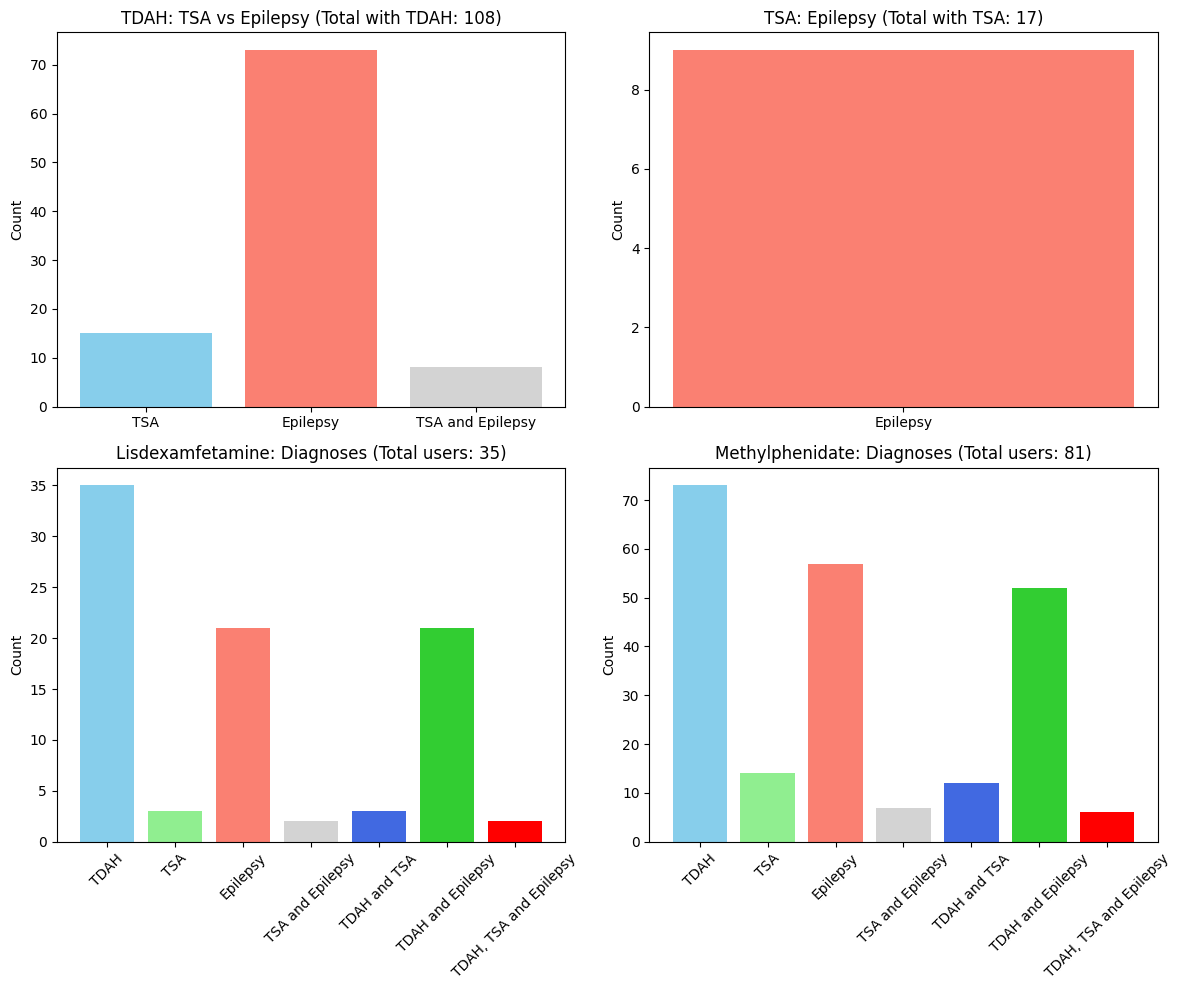

In [77]:
# Analysis using df_merged (which still has TDAH, TSA and Epilepsy)
# Total number of subjects in df_merged:
print("Total subjects in df_merged:", df_merged.shape[0])

# 1. Out of those with TDAH, count how many are also TSA and how many are Epilepsy
tdah = df_merged[df_merged["TDAH"] == 1]
print("Subjects with TDAH:", tdah.shape[0])
tdah_tsa = tdah[tdah["TSA"] == "1"]
tdah_epi = tdah[tdah["Epilepsy"] == "1"]
print("Among 108 TDAH subjects:")
print("  TSA:", tdah_tsa.shape[0], "({:.1f}%)".format(100*tdah_tsa.shape[0]/tdah.shape[0] if tdah.shape[0] else 0))
print("  Epilepsy:", tdah_epi.shape[0], "({:.1f}%)".format(100*tdah_epi.shape[0]/tdah.shape[0] if tdah.shape[0] else 0))
# add information adbout the number of subjects with both EPilepsy and TSA
tdah_epi_tsa = tdah[tdah["TSA"] == "1"][tdah["Epilepsy"] == "1"]
print("  TSA and Epilepsy:", tdah_epi_tsa.shape[0], "({:.1f}%)".format(100*tdah_epi_tsa.shape[0]/tdah.shape[0] if tdah.shape[0] else 0))

# 2. Out of those with TSA, count how many are also Epilepsy
tsa = df_merged[df_merged["TSA"] == "1"]
print("Subjects with TSA:", tsa.shape[0])
tsa_epi = tsa[tsa["Epilepsy"] == "1"]
print("Among TSA subjects:")
print("  Epilepsy:", tsa_epi.shape[0], "({:.1f}%)".format(100*tsa_epi.shape[0]/tsa.shape[0] if tsa.shape[0] else 0))

# 3. Out of those taking Lisdexamfetamine, count the diagnoses
lisd = df_merged[df_merged["psychostimulant_description"]=="Lisdexamfetamine"]
print("\nLisdexamfetamine users:", lisd.shape[0])
lisd_tdah = lisd[lisd["TDAH"] == 1]
lisd_tsa = lisd[lisd["TSA"] == "1"]
lisd_epi = lisd[lisd["Epilepsy"] == "1"]
print("Among Lisdexamfetamine users:")
print("  TDAH:", lisd_tdah.shape[0], "({:.1f}%)".format(100*lisd_tdah.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))
print("  TSA:", lisd_tsa.shape[0], "({:.1f}%)".format(100*lisd_tsa.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))
print("  Epilepsy:", lisd_epi.shape[0], "({:.1f}%)".format(100*lisd_epi.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))
# Add information about the number of subjects with both Epilepsy and TSA
# Add information about the number of subjects with both TDAH and TSA
# Add information about the number of subjects with both TDAH and Epilepsy
# Add information about the number of subjects with all three diagnoses
lisd_epi_tsa = lisd[lisd["TSA"] == "1"][lisd["Epilepsy"] == "1"]
lisd_tdah_tsa = lisd[lisd["TDAH"] == 1][lisd["TSA"] == "1"]
lisd_tdah_epi = lisd[lisd["TDAH"] == 1][lisd["Epilepsy"] == "1"]
lisd_all = lisd[lisd["TDAH"] == 1][lisd["TSA"] == "1"][lisd["Epilepsy"] == "1"]
print("  TSA and Epilepsy:", lisd_epi_tsa.shape[0], "({:.1f}%)".format(100*lisd_epi_tsa.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))
print("  TDAH and TSA:", lisd_tdah_tsa.shape[0], "({:.1f}%)".format(100*lisd_tdah_tsa.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))
print("  TDAH and Epilepsy:", lisd_tdah_epi.shape[0], "({:.1f}%)".format(100*lisd_tdah_epi.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))
print("  TDAH, TSA and Epilepsy:", lisd_all.shape[0], "({:.1f}%)".format(100*lisd_all.shape[0]/lisd.shape[0] if lisd.shape[0] else 0))


# 4. Out of those taking Methylphenidate, count the diagnoses
methyl = df_merged[df_merged["psychostimulant_description"]=="Methylphenidate"]
print("\nMethylphenidate users:", methyl.shape[0])
methyl_tdah = methyl[methyl["TDAH"] == 1]
methyl_tsa = methyl[methyl["TSA"] == "1"]
methyl_epi = methyl[methyl["Epilepsy"] == "1"]
print("Among Methylphenidate users:")
print("  TDAH:", methyl_tdah.shape[0], "({:.1f}%)".format(100*methyl_tdah.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
print("  TSA:", methyl_tsa.shape[0], "({:.1f}%)".format(100*methyl_tsa.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
print("  Epilepsy:", methyl_epi.shape[0], "({:.1f}%)".format(100*methyl_epi.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
# Add information about the number of subjects with both Epilepsy and TSA
# Add information about the number of subjects with both TDAH and TSA
# Add information about the number of subjects with both TDAH and Epilepsy
# Add information about the number of subjects with all three diagnoses
methyl_epi_tsa = methyl[methyl["TSA"] == "1"][methyl["Epilepsy"] == "1"]
methyl_tdah_tsa = methyl[methyl["TDAH"] == 1][methyl["TSA"] == "1"]
methyl_tdah_epi = methyl[methyl["TDAH"] == 1][methyl["Epilepsy"] == "1"]
methyl_all = methyl[methyl["TDAH"] == 1][methyl["TSA"] == "1"][methyl["Epilepsy"] == "1"]
print("  TSA and Epilepsy:", methyl_epi_tsa.shape[0], "({:.1f}%)".format(100*methyl_epi_tsa.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
print("  TDAH and TSA:", methyl_tdah_tsa.shape[0], "({:.1f}%)".format(100*methyl_tdah_tsa.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
print("  TDAH and Epilepsy:", methyl_tdah_epi.shape[0], "({:.1f}%)".format(100*methyl_tdah_epi.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
print("  TDAH, TSA and Epilepsy:", methyl_all.shape[0], "({:.1f}%)".format(100*methyl_all.shape[0]/methyl.shape[0] if methyl.shape[0] else 0))
# Plot charts for visualization
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# Chart 1: TDAH subjects: TSA vs Epilepsy
# add column for intersection of TSA and Epilepsy
labels = ['TSA', 'Epilepsy', 'TSA and Epilepsy']
values = [tdah_tsa.shape[0], tdah_epi.shape[0], tdah_epi_tsa.shape[0]]
axs[0,0].bar(labels, values, color=['skyblue', 'salmon', 'lightgray'])
axs[0,0].set_title("TDAH: TSA vs Epilepsy (Total with TDAH: {})".format(tdah.shape[0]))
axs[0,0].set_ylabel("Count")

# Chart 2: TSA subjects: Epilepsy
axs[0,1].bar(['Epilepsy'], [tsa_epi.shape[0]], color='salmon')
axs[0,1].set_title("TSA: Epilepsy (Total with TSA: {})".format(tsa.shape[0]))
axs[0,1].set_ylabel("Count")

# Chart 3: Lisdexamfetamine users diagnoses
# add column for intersection of TSA and Epilepsy
# add column for intersection of TDAH and TSA
# add column for intersection of TDAH and Epilepsy
# add column for intersection of TDAH, TSA and Epilepsy

labels = ['TDAH', 'TSA', 'Epilepsy', 'TSA and Epilepsy', 'TDAH and TSA', 'TDAH and Epilepsy', 'TDAH, TSA and Epilepsy']
values = [lisd_tdah.shape[0], lisd_tsa.shape[0], lisd_epi.shape[0], lisd_epi_tsa.shape[0], lisd_tdah_tsa.shape[0], lisd_tdah_epi.shape[0], lisd_all.shape[0]]
axs[1,0].bar(labels, values, color=['skyblue','lightgreen','salmon', 'lightgray', 'royalblue', 'limegreen', 'red'])
axs[1,0].set_xticklabels(labels, rotation=45)
axs[1,0].set_title("Lisdexamfetamine: Diagnoses (Total users: {})".format(lisd.shape[0]))
axs[1,0].set_ylabel("Count")

# Chart 4: Methylphenidate users diagnoses
# add column for intersection of TSA and Epilepsy
# add column for intersection of TDAH and TSA
# add column for intersection of TDAH and Epilepsy
# add column for intersection of TDAH, TSA and Epilepsy

labels = ['TDAH', 'TSA', 'Epilepsy', 'TSA and Epilepsy', 'TDAH and TSA', 'TDAH and Epilepsy', 'TDAH, TSA and Epilepsy']
values = [methyl_tdah.shape[0], methyl_tsa.shape[0], methyl_epi.shape[0], methyl_epi_tsa.shape[0], methyl_tdah_tsa.shape[0], methyl_tdah_epi.shape[0], methyl_all.shape[0]]
axs[1,1].set_xticklabels(labels, rotation=45)
axs[1,1].bar(labels, values, color=['skyblue','lightgreen','salmon', 'lightgray', 'royalblue', 'limegreen', 'red'])
axs[1,1].set_title("Methylphenidate: Diagnoses (Total users: {})".format(methyl.shape[0]))
axs[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [8]:
df_merged.drop(columns=['psychostimulant_description', "TDAH", "TSA", "Epilepsy", "Age", "Sex", "Psychostimulant (y/n)", "age",  'dataset',
 'group',
 'id',
 'sex',
 'task',], inplace=True)

In [9]:
df_merged.drop(columns=['subject'], inplace=True)

In [10]:
df_merged.rename(columns={'psychostimulant_category':'group'}, inplace=True)

In [11]:
# create a copy of df_merged with equal number of rows for each group
df_group_1 = df_merged[df_merged['group'] == "1"]
df_group_2 = df_merged[df_merged['group'] == "2"]
df_group_2 = df_group_2.sample(n=len(df_group_1), random_state=42)
df_merged_balanced = pd.concat([df_group_1, df_group_2])

In [12]:
from ml_pipelines.run_ml_pipe import run_analysis0, run_analysis5, run_analysis7

In [51]:
analysis_type = "meds"
run_analysis0(df_merged_balanced, analysis_type)

2025-02-28 12:43:35 [INFO] Running pipeline for feature: feature-RelativeBandPower1.bands-alpha.spaces-A1
2025-02-28 12:43:35 [INFO] Decision Tree Accuracy: 0.5857
2025-02-28 12:43:36 [INFO] Random Forest Accuracy: 0.5857
2025-02-28 12:43:36 [INFO] Gradient Boosting Accuracy: 0.5857
2025-02-28 12:43:36 [INFO] K-Nearest Neighbors Accuracy: 0.5714
2025-02-28 12:43:36 [INFO] Running pipeline for feature: feature-RelativeBandPower1.bands-alpha.spaces-A2
2025-02-28 12:43:36 [INFO] Decision Tree Accuracy: 0.4429
2025-02-28 12:43:36 [INFO] Random Forest Accuracy: 0.4429
2025-02-28 12:43:36 [INFO] Gradient Boosting Accuracy: 0.4429
2025-02-28 12:43:36 [INFO] K-Nearest Neighbors Accuracy: 0.5429
2025-02-28 12:43:36 [INFO] Running pipeline for feature: feature-RelativeBandPower1.bands-alpha.spaces-C3
2025-02-28 12:43:36 [INFO] Decision Tree Accuracy: 0.3286
2025-02-28 12:43:36 [INFO] Random Forest Accuracy: 0.3286
2025-02-28 12:43:37 [INFO] Gradient Boosting Accuracy: 0.3286
2025-02-28 12:43:37 

In [20]:

import pickle
import mne
import numpy as np
import matplotlib.pyplot as plt

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
          "#ff9896", "#aec7e8", "#ffbb78", "#98df8a", "#ff9896"]
colors_models = {"Random Forest": "#1f77b4", "Decision Tree": "#ff7f0e", "Gradient Boosting": "#2ca02c", "K-Nearest Neighbors": "#d62728"}
list_features = ['RelativeBandPower1.bands-alpha', 'RelativeBandPower1.bands-beta', 'RelativeBandPower1.bands-delta', 'RelativeBandPower1.bands-theta', 'detrendedFluctuation', 'higuchiFd', 'hjorthComplexity', 'hjorthMobility', 'katzFd', 'lzivComplexity', 'numZerocross', 'permEntropy', 'petrosianFd', 'spectralEntropy', 'svdEntropy']
montage = mne.channels.make_standard_montage("standard_1020")
ch_pos = montage.get_positions()["ch_pos"]

color_features = dict(zip(list_features, colors))

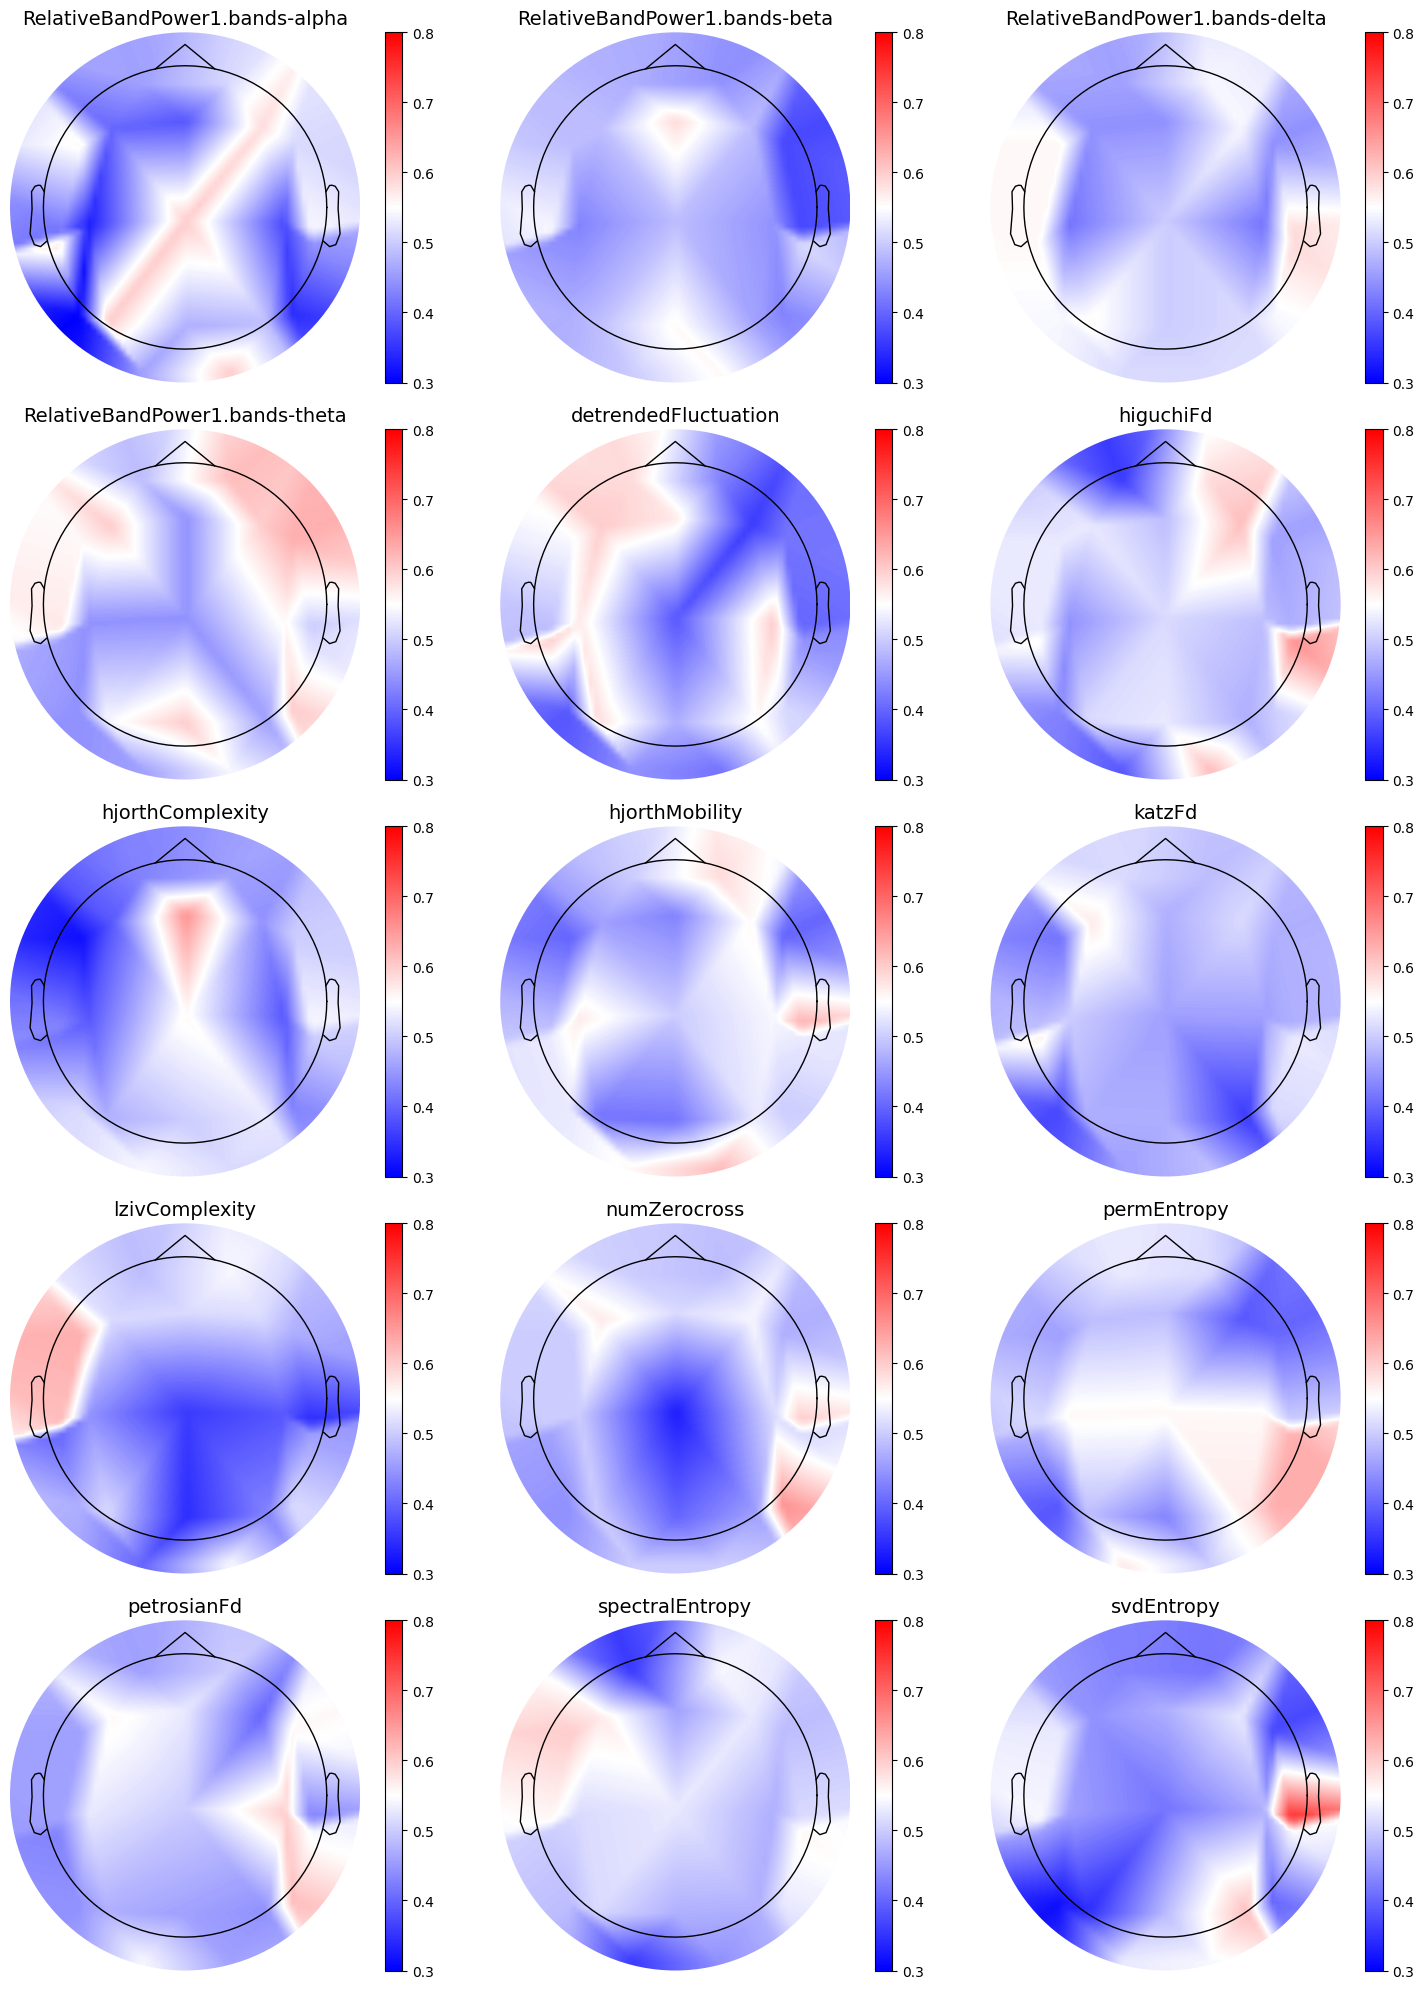

In [60]:
# Base models, Single feature single sensor ; plot topomaps
with open(os.path.join(results_dir, "",f"single_feature_baseline_results_meds.pkl"), 'rb') as f:
    results = pickle.load(f)

selected_model = "Random Forest"
feature_sensor_results = {}
for feat, res in results.items():
    base_feature = feat.split('.spaces-')[0]
    sensor = feat.split('.spaces-')[-1]
    feature_sensor_results.setdefault(base_feature, {})[sensor] = res[0][selected_model]


fig, axs = plt.subplots(5, 3, figsize=(15, 20))
axs = axs.flatten()
pos = np.array([ch_pos[s][:2] for s in feature_sensor_results["feature-RelativeBandPower1.bands-alpha"].keys()])  # use first two coords (x,y)
names = list(feature_sensor_results["feature-RelativeBandPower1.bands-alpha"].keys())
for feat, sensor_dict, ax in zip(feature_sensor_results.keys(), feature_sensor_results.values(), axs):
    acc = list(sensor_dict.values())
    # Plot the topomap.
    im, _ = mne.viz.plot_topomap(acc, pos, axes=ax, contours=0, sensors=False,
                             vlim=(0.3, 0.8), cmap="bwr", show=False, image_interp="linear")
    feat = feat.replace("feature-", "")
    ax.set_title(f"{feat}", fontsize=14)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
# plt.savefig(os.path.join("..", "plots", f"{selected_model}_single_feature_classification_HP_{analysis_type}.pdf"), dpi=300)
# plt.savefig(os.path.join("..", "plots", f"{selected_model}_single_feature_classification_HP_{analysis_type}.png"), dpi=300)

In [65]:
analysis_type

'meds'

In [63]:
run_analysis5(df_merged_balanced, analysis_type)

2025-02-28 12:52:55 [INFO] Decision Tree Accuracy: 0.6000
2025-02-28 12:52:55 [INFO] Random Forest Accuracy: 0.4857
2025-02-28 12:52:56 [INFO] Gradient Boosting Accuracy: 0.4857
2025-02-28 12:52:57 [INFO] K-Nearest Neighbors Accuracy: 0.3571
2025-02-28 12:52:57 [INFO] Done analysis 5!


In [66]:
# multi feature all sensors HP bar plots
with open(os.path.join(results_dir, "baseline_results_all_feat_all_sensors_meds.pkl"), "rb") as f:
    feature_results = pickle.load(f)

In [68]:
feature_results

{'results': {'Decision Tree': 0.6,
  'Random Forest': 0.48571428571428565,
  'Gradient Boosting': 0.48571428571428565,
  'K-Nearest Neighbors': 0.3571428571428571},
 'models': {'Decision Tree': DecisionTreeClassifier(random_state=42),
  'Random Forest': RandomForestClassifier(random_state=42),
  'Gradient Boosting': GradientBoostingClassifier(random_state=42),
  'K-Nearest Neighbors': KNeighborsClassifier()}}

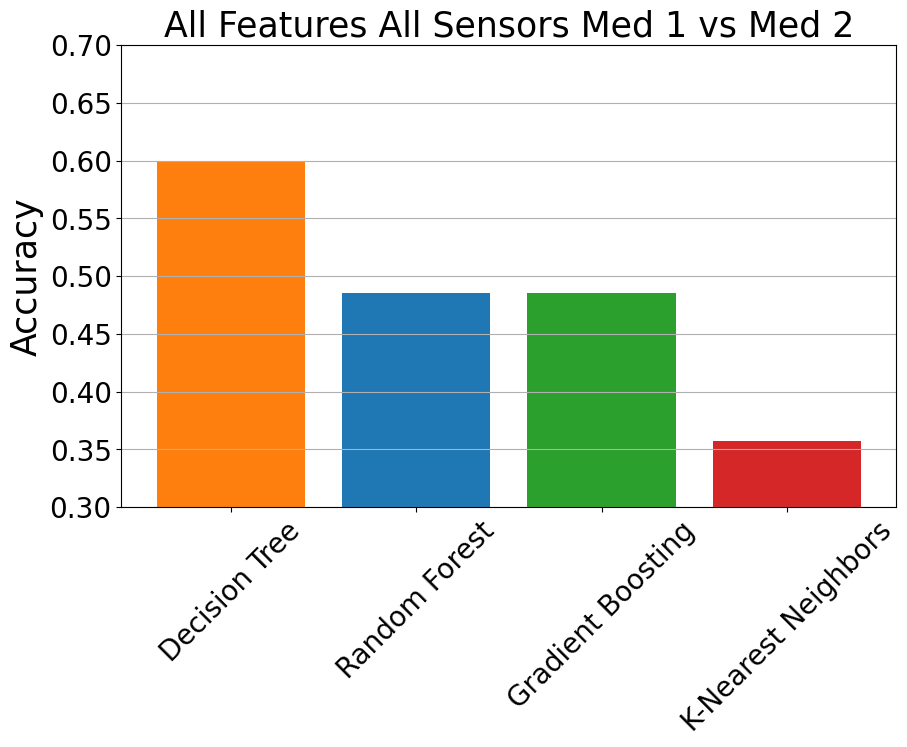

In [71]:
fig, axs = plt.subplots(figsize=(10, 6))
acc = feature_results["results"]
models = list(acc.keys())
accuracies = list(acc.values())
# Sort by accuracy
accuracies, models = zip(*sorted(zip(accuracies, models), reverse=True))
colors = [colors_models[model] for model in models]
axs.bar(models, accuracies, color=colors)
axs.set_title("All Features All Sensors Med 1 vs Med 2", fontsize=25)
axs.set_ylabel("Accuracy", fontsize=25)
axs.set_ylim(0.3, 0.7)
axs.set_xticks(ticks=range(len(models)))
axs.set_xticklabels(models, fontsize=20, rotation=45)
axs.tick_params(axis="y", labelsize=20)
axs.grid(axis='y')
# plt.savefig(os.path.join("..", "plots", f"baseline_results_all_feat_all_sensors_{analysis_type}.pdf"), bbox_inches='tight', dpi=300)
# plt.savefig(os.path.join("..", "plots", f"baseline_results_all_feat_all_sensors_{analysis_type}.png"), bbox_inches='tight', dpi=300)

In [14]:
analysis_type = "meds"
run_analysis7(df_merged_balanced, analysis_type, 10)

2025-02-28 13:06:21 [INFO] Running feature selection for model: Decision Tree
2025-02-28 13:06:21 [INFO] Processing 1 features
2025-02-28 13:06:29 [INFO] Accuracy with 1 features: 0.7571
2025-02-28 13:06:29 [INFO] Processing 2 features
2025-02-28 13:06:37 [INFO] Accuracy with 2 features: 0.7571
2025-02-28 13:06:37 [INFO] Processing 3 features
2025-02-28 13:06:50 [INFO] Accuracy with 3 features: 0.8143
2025-02-28 13:06:50 [INFO] Processing 4 features
2025-02-28 13:07:06 [INFO] Accuracy with 4 features: 0.8000
2025-02-28 13:07:06 [INFO] Processing 5 features
2025-02-28 13:07:28 [INFO] Accuracy with 5 features: 0.8286
2025-02-28 13:07:28 [INFO] Processing 6 features
2025-02-28 13:07:53 [INFO] Accuracy with 6 features: 0.7857
2025-02-28 13:07:53 [INFO] Processing 7 features
2025-02-28 13:08:22 [INFO] Accuracy with 7 features: 0.7714
2025-02-28 13:08:22 [INFO] Processing 8 features
2025-02-28 13:08:55 [INFO] Accuracy with 8 features: 0.7714
2025-02-28 13:08:55 [INFO] Processing 9 features
2

In [16]:
# single feature sensor selection adolescent

import pickle
analysis_type = 'adolescent'
with open(os.path.join(results_dir, "",f"feature_selection_all_feat_all_sensors_meds.pkl"), 'rb') as f:
    results = pickle.load(f)

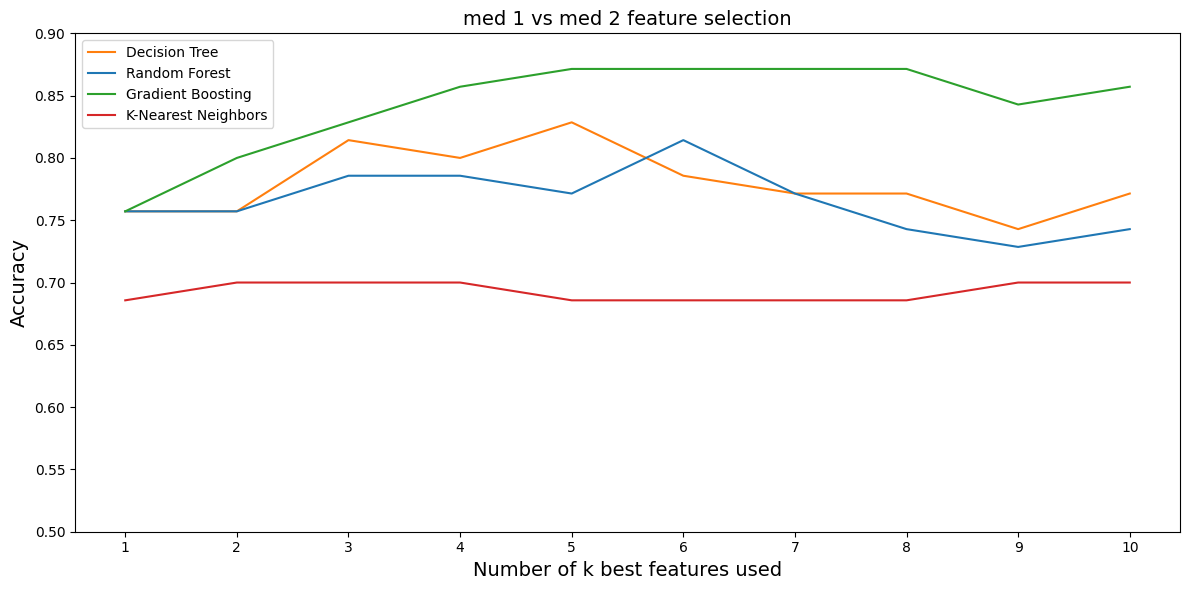

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
model_accuracies = []
for model, model_results in results.items():
    n_feature_accuracies = []
    for n_features, results_1 in model_results.items():
        acc = results_1["accuracy"]
        n_feature_accuracies.append(acc)
    model_accuracies.append(n_feature_accuracies)
for model_acc,  model in zip(model_accuracies, ["Decision Tree", "Random Forest", 'Gradient Boosting', 'K-Nearest Neighbors']):
    ax.plot(range(1, 11), model_acc, label=model, color=colors_models[model])
    ax.set_xticks(range(1, 11))
ax.set_ylim(0.5, 0.9)
ax.set_title("med 1 vs med 2 feature selection", fontsize=14)
ax.set_xlabel("Number of k best features used", fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)
ax.legend()
plt.tight_layout()
# plt.savefig(os.path.join("..", "plots", f"sensor_selection_per_feature_search_adolescent.pdf"), dpi=300)
# plt.savefig(os.path.join("..", "plots", f"sensor_selection_per_feature_search_adolescent.png"), dpi=300)

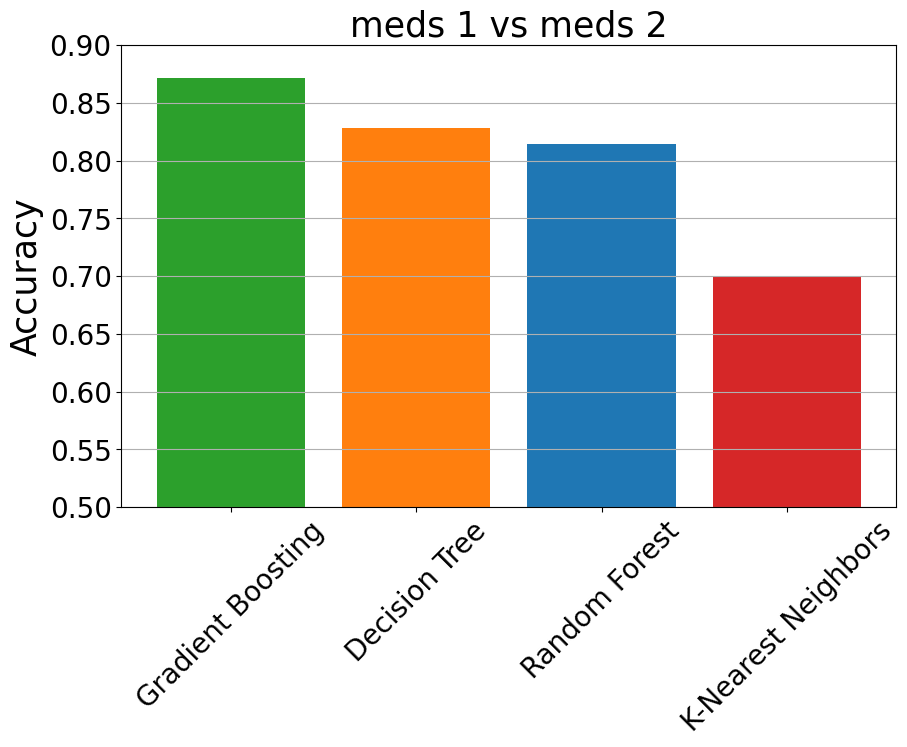

In [27]:
analysis_type = 'meds'
fig, axs = plt.subplots(figsize=(10, 6))
models = ["Decision Tree", "Random Forest", 'Gradient Boosting', 'K-Nearest Neighbors']
accuracies = [max(model_acc) for model_acc in model_accuracies] 
# Sort by accuracy
accuracies, models = zip(*sorted(zip(accuracies, models), reverse=True))
colors = [colors_models[model] for model in models]
axs.bar(models, accuracies, color=colors)
axs.set_title("meds 1 vs meds 2", fontsize=25)
axs.set_ylabel("Accuracy", fontsize=25)
axs.set_ylim(0.5, 0.9)
axs.set_xticks(ticks=range(len(models)))
axs.set_xticklabels(models, fontsize=20, rotation=45)
axs.tick_params(axis="y", labelsize=20)
axs.grid(axis='y')
# plt.savefig(os.path.join("..", "plots", f"all_sensors_all_features_multi_classification_results_{analysis_type}.pdf"), bbox_inches='tight', dpi=300)
# plt.savefig(os.path.join("..", "plots", f"all_sensors_all_features_multi_classification_results_{analysis_type}.png"), bbox_inches='tight', dpi=300)

In [2]:
import sys
sys.path.append('..')
from utils.config import data_dir, results_dir, derivatives_dir
import os
import mne
from mne_bids import BIDSPath

In [6]:
derivatives_dir = "/Users/hamzaabdelhedi/Projects/data/EEG_psychostimulant_data/EEG_psychostimulants_2025-02/derivatives"

In [15]:
bids_path = BIDSPath(
    root=derivatives_dir,
    subject="1",
    session="01",
    task="RESTING",
    run="01",
    suffix="eeg",
    extension=".vhdr",
    datatype="eeg",
    processing="cleaned",
)


In [16]:
# Load the data
raw = mne.io.read_raw_brainvision(bids_path, preload=True)

Extracting parameters from /Users/hamzaabdelhedi/Projects/data/EEG_psychostimulant_data/EEG_psychostimulants_2025-02/derivatives/sub-1/ses-01/eeg/sub-1_ses-01_task-RESTING_run-01_proc-cleaned_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 310399  =      0.000 ...  1551.995 secs...


In [19]:
# Get EEG data as a numpy array (channels x timepoints)
data = raw.get_data()  

# Loop over channel names and compute min and max
for i, sensor in enumerate(raw.ch_names):
    ch_min = data[i].min()
    ch_max = data[i].max()
    print(f"Sensor: {sensor}, min: {ch_min:.3g}, max: {ch_max:.3g}")

Sensor: Fp1, min: -0.000285, max: 0.000366
Sensor: Fp2, min: -0.000239, max: 0.000365
Sensor: F3, min: -0.000305, max: 0.000172
Sensor: F4, min: -7.98e-05, max: 9.61e-05
Sensor: C3, min: -8.86e-05, max: 7.24e-05
Sensor: C4, min: -7.3e-05, max: 8.94e-05
Sensor: P3, min: -8.12e-05, max: 6.72e-05
Sensor: P4, min: -7.91e-05, max: 6.91e-05
Sensor: O1, min: -0.000148, max: 0.000277
Sensor: O2, min: -0.000113, max: 8.67e-05
Sensor: F7, min: -0.000413, max: 0.00025
Sensor: F8, min: -0.000271, max: 0.000187
Sensor: T3, min: -0.000269, max: 0.000152
Sensor: T4, min: -0.000515, max: 0.000197
Sensor: T5, min: -0.000173, max: 0.00023
Sensor: T6, min: -0.000146, max: 0.000197
Sensor: Fz, min: -0.000127, max: 0.000112
Sensor: Cz, min: -9.34e-05, max: 6.53e-05
Sensor: Pz, min: -8.02e-05, max: 6.14e-05
Sensor: A1, min: -0.003, max: 0.00339
Sensor: A2, min: -0.00228, max: 0.00278


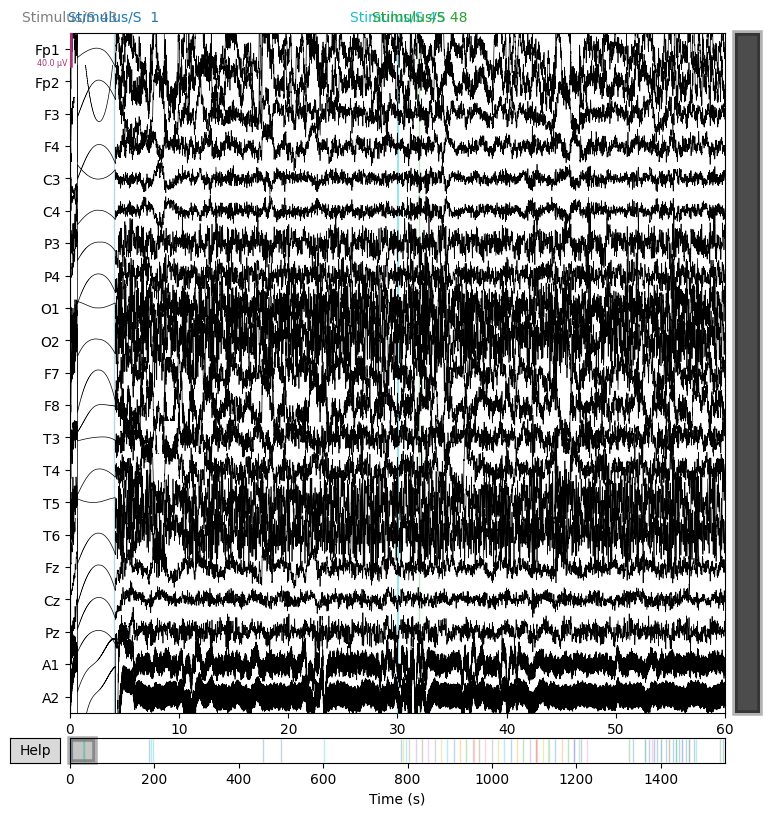

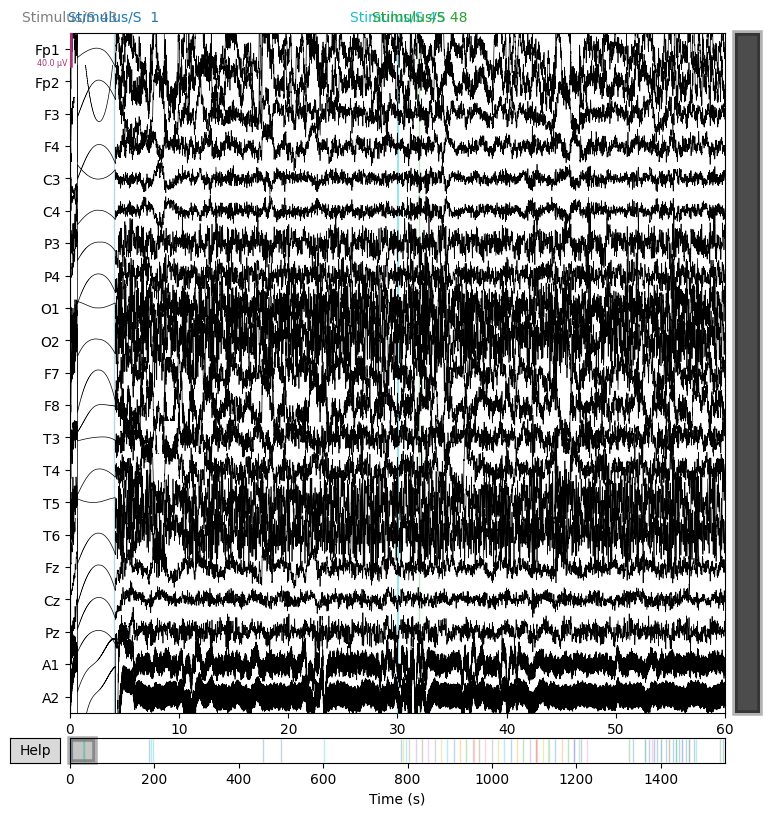

In [21]:
raw.plot(duration=60, title="EEG data",  n_channels=32)

In [ ]:
# I have a numpy array with subjects where each index i represents to what subject the embeddings of index i belong! We can have multiple embeddings per subject.
# i want to average the embeddings of each subject and then plot the embeddings of each subject in a 2D space 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the embeddings
embeddings = np.load("embeddings.npy")
# Load the subjects
subjects = np.load("subjects.npy")
# subjects could be 1 1 1 1 1 2 2 2 2 2 2 3 3 3 3 3 3  4 4 4 4 4  4
# get embedding i for all subjects
embeddings_i = embeddings[subjects == 1]

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file containing embeddings and age group information
df = pd.read_csv("/Users/hamzaabdelhedi/Projects/data/EEG_psychostimulant_data/EEG_psychostimulants_2025-02/csv/features_with_age_group.csv")

df.columns

Index(['dataset', 'group', 'id', 'subject', 'task',
       'feature-RelativeBandPower1.bands-alpha.spaces-A1',
       'feature-RelativeBandPower1.bands-alpha.spaces-A2',
       'feature-RelativeBandPower1.bands-alpha.spaces-C3',
       'feature-RelativeBandPower1.bands-alpha.spaces-C4',
       'feature-RelativeBandPower1.bands-alpha.spaces-Cz',
       ...
       'feature-svdEntropy.spaces-P3', 'feature-svdEntropy.spaces-P4',
       'feature-svdEntropy.spaces-Pz', 'feature-svdEntropy.spaces-T3',
       'feature-svdEntropy.spaces-T4', 'feature-svdEntropy.spaces-T5',
       'feature-svdEntropy.spaces-T6', 'age', 'sex', 'age_group'],
      dtype='object', length=323)

In [7]:
patients_demographics = pd.read_csv("/Users/hamzaabdelhedi/Projects/data/EEG_psychostimulant_data/EEG_psychostimulants_2025-02/csv/patients_demog.csv")

In [9]:
list(df_merged.columns)

['subject',
 'psychostimulant_description',
 'psychostimulant_category',
 'TDAH',
 'TSA',
 'Epilepsy',
 'Age',
 'Sex',
 'Psychostimulant (y/n)',
 'age',
 'dataset',
 'group',
 'id',
 'sex',
 'task',
 'feature-RelativeBandPower1.bands-alpha.spaces-A1',
 'feature-RelativeBandPower1.bands-alpha.spaces-A2',
 'feature-RelativeBandPower1.bands-alpha.spaces-C3',
 'feature-RelativeBandPower1.bands-alpha.spaces-C4',
 'feature-RelativeBandPower1.bands-alpha.spaces-Cz',
 'feature-RelativeBandPower1.bands-alpha.spaces-F3',
 'feature-RelativeBandPower1.bands-alpha.spaces-F4',
 'feature-RelativeBandPower1.bands-alpha.spaces-F7',
 'feature-RelativeBandPower1.bands-alpha.spaces-F8',
 'feature-RelativeBandPower1.bands-alpha.spaces-Fp1',
 'feature-RelativeBandPower1.bands-alpha.spaces-Fp2',
 'feature-RelativeBandPower1.bands-alpha.spaces-Fz',
 'feature-RelativeBandPower1.bands-alpha.spaces-O1',
 'feature-RelativeBandPower1.bands-alpha.spaces-O2',
 'feature-RelativeBandPower1.bands-alpha.spaces-P3',
 'fe

In [130]:
# drop columns: 
df_merged.drop(columns= ['feature-RelativeBandPower1.bands-alpha.spaces-A1',
 'feature-RelativeBandPower1.bands-alpha.spaces-A2',
 'feature-RelativeBandPower1.bands-alpha.spaces-C3',
 'feature-RelativeBandPower1.bands-alpha.spaces-C4',
 'feature-RelativeBandPower1.bands-alpha.spaces-Cz',
 'feature-RelativeBandPower1.bands-alpha.spaces-F3',
 'feature-RelativeBandPower1.bands-alpha.spaces-F4',
 'feature-RelativeBandPower1.bands-alpha.spaces-F7',
 'feature-RelativeBandPower1.bands-alpha.spaces-F8',
 'feature-RelativeBandPower1.bands-alpha.spaces-Fp1',
 'feature-RelativeBandPower1.bands-alpha.spaces-Fp2',
 'feature-RelativeBandPower1.bands-alpha.spaces-Fz',
 'feature-RelativeBandPower1.bands-alpha.spaces-O1',
 'feature-RelativeBandPower1.bands-alpha.spaces-O2',
 'feature-RelativeBandPower1.bands-alpha.spaces-P3',
 'feature-RelativeBandPower1.bands-alpha.spaces-P4',
 'feature-RelativeBandPower1.bands-alpha.spaces-Pz',
 'feature-RelativeBandPower1.bands-alpha.spaces-T3',
 'feature-RelativeBandPower1.bands-alpha.spaces-T4',
 'feature-RelativeBandPower1.bands-alpha.spaces-T5',
 'feature-RelativeBandPower1.bands-alpha.spaces-T6',
 'feature-RelativeBandPower1.bands-beta.spaces-A1',
 'feature-RelativeBandPower1.bands-beta.spaces-A2',
 'feature-RelativeBandPower1.bands-beta.spaces-C3',
 'feature-RelativeBandPower1.bands-beta.spaces-C4',
 'feature-RelativeBandPower1.bands-beta.spaces-Cz',
 'feature-RelativeBandPower1.bands-beta.spaces-F3',
 'feature-RelativeBandPower1.bands-beta.spaces-F4',
 'feature-RelativeBandPower1.bands-beta.spaces-F7',
 'feature-RelativeBandPower1.bands-beta.spaces-F8',
 'feature-RelativeBandPower1.bands-beta.spaces-Fp1',
 'feature-RelativeBandPower1.bands-beta.spaces-Fp2',
 'feature-RelativeBandPower1.bands-beta.spaces-Fz',
 'feature-RelativeBandPower1.bands-beta.spaces-O1',
 'feature-RelativeBandPower1.bands-beta.spaces-O2',
 'feature-RelativeBandPower1.bands-beta.spaces-P3',
 'feature-RelativeBandPower1.bands-beta.spaces-P4',
 'feature-RelativeBandPower1.bands-beta.spaces-Pz',
 'feature-RelativeBandPower1.bands-beta.spaces-T3',
 'feature-RelativeBandPower1.bands-beta.spaces-T4',
 'feature-RelativeBandPower1.bands-beta.spaces-T5',
 'feature-RelativeBandPower1.bands-beta.spaces-T6',
 'feature-RelativeBandPower1.bands-delta.spaces-A1',
 'feature-RelativeBandPower1.bands-delta.spaces-A2',
 'feature-RelativeBandPower1.bands-delta.spaces-C3',
 'feature-RelativeBandPower1.bands-delta.spaces-C4',
 'feature-RelativeBandPower1.bands-delta.spaces-Cz',
 'feature-RelativeBandPower1.bands-delta.spaces-F3',
 'feature-RelativeBandPower1.bands-delta.spaces-F4',
 'feature-RelativeBandPower1.bands-delta.spaces-F7',
 'feature-RelativeBandPower1.bands-delta.spaces-F8',
 'feature-RelativeBandPower1.bands-delta.spaces-Fp1',
 'feature-RelativeBandPower1.bands-delta.spaces-Fp2',
 'feature-RelativeBandPower1.bands-delta.spaces-Fz',
 'feature-RelativeBandPower1.bands-delta.spaces-O1',
 'feature-RelativeBandPower1.bands-delta.spaces-O2',
 'feature-RelativeBandPower1.bands-delta.spaces-P3',
 'feature-RelativeBandPower1.bands-delta.spaces-P4',
 'feature-RelativeBandPower1.bands-delta.spaces-Pz',
 'feature-RelativeBandPower1.bands-delta.spaces-T3',
 'feature-RelativeBandPower1.bands-delta.spaces-T4',
 'feature-RelativeBandPower1.bands-delta.spaces-T5',
 'feature-RelativeBandPower1.bands-delta.spaces-T6',
 'feature-RelativeBandPower1.bands-theta.spaces-A1',
 'feature-RelativeBandPower1.bands-theta.spaces-A2',
 'feature-RelativeBandPower1.bands-theta.spaces-C3',
 'feature-RelativeBandPower1.bands-theta.spaces-C4',
 'feature-RelativeBandPower1.bands-theta.spaces-Cz',
 'feature-RelativeBandPower1.bands-theta.spaces-F3',
 'feature-RelativeBandPower1.bands-theta.spaces-F4',
 'feature-RelativeBandPower1.bands-theta.spaces-F7',
 'feature-RelativeBandPower1.bands-theta.spaces-F8',
 'feature-RelativeBandPower1.bands-theta.spaces-Fp1',
 'feature-RelativeBandPower1.bands-theta.spaces-Fp2',
 'feature-RelativeBandPower1.bands-theta.spaces-Fz',
 'feature-RelativeBandPower1.bands-theta.spaces-O1',
 'feature-RelativeBandPower1.bands-theta.spaces-O2',
 'feature-RelativeBandPower1.bands-theta.spaces-P3',
 'feature-RelativeBandPower1.bands-theta.spaces-P4',
 'feature-RelativeBandPower1.bands-theta.spaces-Pz',
 'feature-RelativeBandPower1.bands-theta.spaces-T3',
 'feature-RelativeBandPower1.bands-theta.spaces-T4',
 'feature-RelativeBandPower1.bands-theta.spaces-T5',
 'feature-RelativeBandPower1.bands-theta.spaces-T6',
 'feature-detrendedFluctuation.spaces-A1',
 'feature-detrendedFluctuation.spaces-A2',
 'feature-detrendedFluctuation.spaces-C3',
 'feature-detrendedFluctuation.spaces-C4',
 'feature-detrendedFluctuation.spaces-Cz',
 'feature-detrendedFluctuation.spaces-F3',
 'feature-detrendedFluctuation.spaces-F4',
 'feature-detrendedFluctuation.spaces-F7',
 'feature-detrendedFluctuation.spaces-F8',
 'feature-detrendedFluctuation.spaces-Fp1',
 'feature-detrendedFluctuation.spaces-Fp2',
 'feature-detrendedFluctuation.spaces-Fz',
 'feature-detrendedFluctuation.spaces-O1',
 'feature-detrendedFluctuation.spaces-O2',
 'feature-detrendedFluctuation.spaces-P3',
 'feature-detrendedFluctuation.spaces-P4',
 'feature-detrendedFluctuation.spaces-Pz',
 'feature-detrendedFluctuation.spaces-T3',
 'feature-detrendedFluctuation.spaces-T4',
 'feature-detrendedFluctuation.spaces-T5',
 'feature-detrendedFluctuation.spaces-T6',
 'feature-higuchiFd.spaces-A1',
 'feature-higuchiFd.spaces-A2',
 'feature-higuchiFd.spaces-C3',
 'feature-higuchiFd.spaces-C4',
 'feature-higuchiFd.spaces-Cz',
 'feature-higuchiFd.spaces-F3',
 'feature-higuchiFd.spaces-F4',
 'feature-higuchiFd.spaces-F7',
 'feature-higuchiFd.spaces-F8',
 'feature-higuchiFd.spaces-Fp1',
 'feature-higuchiFd.spaces-Fp2',
 'feature-higuchiFd.spaces-Fz',
 'feature-higuchiFd.spaces-O1',
 'feature-higuchiFd.spaces-O2',
 'feature-higuchiFd.spaces-P3',
 'feature-higuchiFd.spaces-P4',
 'feature-higuchiFd.spaces-Pz',
 'feature-higuchiFd.spaces-T3',
 'feature-higuchiFd.spaces-T4',
 'feature-higuchiFd.spaces-T5',
 'feature-higuchiFd.spaces-T6',
 'feature-hjorthComplexity.spaces-A1',
 'feature-hjorthComplexity.spaces-A2',
 'feature-hjorthComplexity.spaces-C3',
 'feature-hjorthComplexity.spaces-C4',
 'feature-hjorthComplexity.spaces-Cz',
 'feature-hjorthComplexity.spaces-F3',
 'feature-hjorthComplexity.spaces-F4',
 'feature-hjorthComplexity.spaces-F7',
 'feature-hjorthComplexity.spaces-F8',
 'feature-hjorthComplexity.spaces-Fp1',
 'feature-hjorthComplexity.spaces-Fp2',
 'feature-hjorthComplexity.spaces-Fz',
 'feature-hjorthComplexity.spaces-O1',
 'feature-hjorthComplexity.spaces-O2',
 'feature-hjorthComplexity.spaces-P3',
 'feature-hjorthComplexity.spaces-P4',
 'feature-hjorthComplexity.spaces-Pz',
 'feature-hjorthComplexity.spaces-T3',
 'feature-hjorthComplexity.spaces-T4',
 'feature-hjorthComplexity.spaces-T5',
 'feature-hjorthComplexity.spaces-T6',
 'feature-hjorthMobility.spaces-A1',
 'feature-hjorthMobility.spaces-A2',
 'feature-hjorthMobility.spaces-C3',
 'feature-hjorthMobility.spaces-C4',
 'feature-hjorthMobility.spaces-Cz',
 'feature-hjorthMobility.spaces-F3',
 'feature-hjorthMobility.spaces-F4',
 'feature-hjorthMobility.spaces-F7',
 'feature-hjorthMobility.spaces-F8',
 'feature-hjorthMobility.spaces-Fp1',
 'feature-hjorthMobility.spaces-Fp2',
 'feature-hjorthMobility.spaces-Fz',
 'feature-hjorthMobility.spaces-O1',
 'feature-hjorthMobility.spaces-O2',
 'feature-hjorthMobility.spaces-P3',
 'feature-hjorthMobility.spaces-P4',
 'feature-hjorthMobility.spaces-Pz',
 'feature-hjorthMobility.spaces-T3',
 'feature-hjorthMobility.spaces-T4',
 'feature-hjorthMobility.spaces-T5',
 'feature-hjorthMobility.spaces-T6',
 'feature-katzFd.spaces-A1',
 'feature-katzFd.spaces-A2',
 'feature-katzFd.spaces-C3',
 'feature-katzFd.spaces-C4',
 'feature-katzFd.spaces-Cz',
 'feature-katzFd.spaces-F3',
 'feature-katzFd.spaces-F4',
 'feature-katzFd.spaces-F7',
 'feature-katzFd.spaces-F8',
 'feature-katzFd.spaces-Fp1',
 'feature-katzFd.spaces-Fp2',
 'feature-katzFd.spaces-Fz',
 'feature-katzFd.spaces-O1',
 'feature-katzFd.spaces-O2',
 'feature-katzFd.spaces-P3',
 'feature-katzFd.spaces-P4',
 'feature-katzFd.spaces-Pz',
 'feature-katzFd.spaces-T3',
 'feature-katzFd.spaces-T4',
 'feature-katzFd.spaces-T5',
 'feature-katzFd.spaces-T6',
 'feature-lzivComplexity.spaces-A1',
 'feature-lzivComplexity.spaces-A2',
 'feature-lzivComplexity.spaces-C3',
 'feature-lzivComplexity.spaces-C4',
 'feature-lzivComplexity.spaces-Cz',
 'feature-lzivComplexity.spaces-F3',
 'feature-lzivComplexity.spaces-F4',
 'feature-lzivComplexity.spaces-F7',
 'feature-lzivComplexity.spaces-F8',
 'feature-lzivComplexity.spaces-Fp1',
 'feature-lzivComplexity.spaces-Fp2',
 'feature-lzivComplexity.spaces-Fz',
 'feature-lzivComplexity.spaces-O1',
 'feature-lzivComplexity.spaces-O2',
 'feature-lzivComplexity.spaces-P3',
 'feature-lzivComplexity.spaces-P4',
 'feature-lzivComplexity.spaces-Pz',
 'feature-lzivComplexity.spaces-T3',
 'feature-lzivComplexity.spaces-T4',
 'feature-lzivComplexity.spaces-T5',
 'feature-lzivComplexity.spaces-T6',
 'feature-numZerocross.spaces-A1',
 'feature-numZerocross.spaces-A2',
 'feature-numZerocross.spaces-C3',
 'feature-numZerocross.spaces-C4',
 'feature-numZerocross.spaces-Cz',
 'feature-numZerocross.spaces-F3',
 'feature-numZerocross.spaces-F4',
 'feature-numZerocross.spaces-F7',
 'feature-numZerocross.spaces-F8',
 'feature-numZerocross.spaces-Fp1',
 'feature-numZerocross.spaces-Fp2',
 'feature-numZerocross.spaces-Fz',
 'feature-numZerocross.spaces-O1',
 'feature-numZerocross.spaces-O2',
 'feature-numZerocross.spaces-P3',
 'feature-numZerocross.spaces-P4',
 'feature-numZerocross.spaces-Pz',
 'feature-numZerocross.spaces-T3',
 'feature-numZerocross.spaces-T4',
 'feature-numZerocross.spaces-T5',
 'feature-numZerocross.spaces-T6',
 'feature-permEntropy.spaces-A1',
 'feature-permEntropy.spaces-A2',
 'feature-permEntropy.spaces-C3',
 'feature-permEntropy.spaces-C4',
 'feature-permEntropy.spaces-Cz',
 'feature-permEntropy.spaces-F3',
 'feature-permEntropy.spaces-F4',
 'feature-permEntropy.spaces-F7',
 'feature-permEntropy.spaces-F8',
 'feature-permEntropy.spaces-Fp1',
 'feature-permEntropy.spaces-Fp2',
 'feature-permEntropy.spaces-Fz',
 'feature-permEntropy.spaces-O1',
 'feature-permEntropy.spaces-O2',
 'feature-permEntropy.spaces-P3',
 'feature-permEntropy.spaces-P4',
 'feature-permEntropy.spaces-Pz',
 'feature-permEntropy.spaces-T3',
 'feature-permEntropy.spaces-T4',
 'feature-permEntropy.spaces-T5',
 'feature-permEntropy.spaces-T6',
 'feature-petrosianFd.spaces-A1',
 'feature-petrosianFd.spaces-A2',
 'feature-petrosianFd.spaces-C3',
 'feature-petrosianFd.spaces-C4',
 'feature-petrosianFd.spaces-Cz',
 'feature-petrosianFd.spaces-F3',
 'feature-petrosianFd.spaces-F4',
 'feature-petrosianFd.spaces-F7',
 'feature-petrosianFd.spaces-F8',
 'feature-petrosianFd.spaces-Fp1',
 'feature-petrosianFd.spaces-Fp2',
 'feature-petrosianFd.spaces-Fz',
 'feature-petrosianFd.spaces-O1',
 'feature-petrosianFd.spaces-O2',
 'feature-petrosianFd.spaces-P3',
 'feature-petrosianFd.spaces-P4',
 'feature-petrosianFd.spaces-Pz',
 'feature-petrosianFd.spaces-T3',
 'feature-petrosianFd.spaces-T4',
 'feature-petrosianFd.spaces-T5',
 'feature-petrosianFd.spaces-T6',
 'feature-spectralEntropy.spaces-A1',
 'feature-spectralEntropy.spaces-A2',
 'feature-spectralEntropy.spaces-C3',
 'feature-spectralEntropy.spaces-C4',
 'feature-spectralEntropy.spaces-Cz',
 'feature-spectralEntropy.spaces-F3',
 'feature-spectralEntropy.spaces-F4',
 'feature-spectralEntropy.spaces-F7',
 'feature-spectralEntropy.spaces-F8',
 'feature-spectralEntropy.spaces-Fp1',
 'feature-spectralEntropy.spaces-Fp2',
 'feature-spectralEntropy.spaces-Fz',
 'feature-spectralEntropy.spaces-O1',
 'feature-spectralEntropy.spaces-O2',
 'feature-spectralEntropy.spaces-P3',
 'feature-spectralEntropy.spaces-P4',
 'feature-spectralEntropy.spaces-Pz',
 'feature-spectralEntropy.spaces-T3',
 'feature-spectralEntropy.spaces-T4',
 'feature-spectralEntropy.spaces-T5',
 'feature-spectralEntropy.spaces-T6',
 'feature-svdEntropy.spaces-A1',
 'feature-svdEntropy.spaces-A2',
 'feature-svdEntropy.spaces-C3',
 'feature-svdEntropy.spaces-C4',
 'feature-svdEntropy.spaces-Cz',
 'feature-svdEntropy.spaces-F3',
 'feature-svdEntropy.spaces-F4',
 'feature-svdEntropy.spaces-F7',
 'feature-svdEntropy.spaces-F8',
 'feature-svdEntropy.spaces-Fp1',
 'feature-svdEntropy.spaces-Fp2',
 'feature-svdEntropy.spaces-Fz',
 'feature-svdEntropy.spaces-O1',
 'feature-svdEntropy.spaces-O2',
 'feature-svdEntropy.spaces-P3',
 'feature-svdEntropy.spaces-P4',
 'feature-svdEntropy.spaces-Pz',
 'feature-svdEntropy.spaces-T3',
 'feature-svdEntropy.spaces-T4',
 'feature-svdEntropy.spaces-T5',
 'feature-svdEntropy.spaces-T6'], inplace=True)

In [131]:
df_merged.TDAH.values

array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1., nan, nan, nan,  1., nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan,  1., nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan,  1., nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan,  1., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan,  1., nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan,  1., nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan,  1.,  1., nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan,  1., nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan,  1., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        1., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  1., nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan,  1., nan, nan, nan,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1

In [132]:
df_merged.TSA

0      0
1      0
2      0
3      0
4      0
      ..
245    0
246    0
247    0
248    0
249    1
Name: TSA, Length: 250, dtype: object

In [ ]:
# I want to color the embeddings based on different groups that we will create:
# Create mapping dictionaries for plotting

# 1. Age groups: 1 for ages 5-12, 2 for ages 13-18
age_groups_mapping = {1: '5-12', 2: '13-18'}

# 2. Psychostimulant category:
# 0: Controls, 1: Lisdexamfetamine, 2: Methylphenidate,
# 3: Lisdexamfetamine, Methylphenidate, 4: Adderall, 5: Dexedrine
psychostimulant_mapping = {
    0: 'Control',
    1: 'Lisdexamfetamine',
    2: 'Methylphenidate',
    3: 'Lisdexamfetamine & Methylphenidate',
    4: 'Adderall',
    5: 'Dexedrine'
}

# 3. TDAH: 0 for control, 1 for patients with TDAH, 2 for patients without TDAH
tdah_mapping = {0: 'Control', 1: 'TDAH', 2: 'Non-TDAH'}

# 4. TSA: 0 for control, 1 for patients with TSA, 2 for patients without TSA,
#    and 3 for potential TSA
tsa_mapping = {0: 'Control', 1: 'TSA', 2: 'Non-TSA', 3: 'Potential TSA'}

# 5. Epilepsy: 0 for control, 1 for patients with Epilepsy, 2 for patients without,
#    and 3 for potential epilepsy
epilepsy_mapping = {0: 'Control', 1: 'Epilepsy', 2: 'Non-Epilepsy', 3: 'Potential Epilepsy'}

# 6. TDAH and TSA:
# 0: Control, 1: Both TDAH and TSA, 2: TDAH only, 3: TSA only, 4: Neither
tdah_tsa_mapping = {0: 'Control', 1: 'TDAH and TSA', 2: 'TDAH only', 3: 'TSA only', 4: 'Neither'}

# 7. TDAH and Epilepsy:
# 0: Control, 1: Both TDAH and Epilepsy, 2: TDAH only, 3: Epilepsy only, 4: Neither
tdah_epi_mapping = {0: 'Control', 1: 'TDAH and Epilepsy', 2: 'TDAH only', 3: 'Epilepsy only', 4: 'Neither'}

# 8. TSA and Epilepsy:
# 0: Control, 1: Both TSA and Epilepsy, 2: TSA only, 3: Epilepsy only, 4: Neither
tsa_epi_mapping = {0: 'Control', 1: 'TSA and Epilepsy', 2: 'TSA only', 3: 'Epilepsy only', 4: 'Neither'}

# 9. TDAH, TSA and Epilepsy:
# 0: Control, 1: All three, 2: TDAH & TSA only, 3: TDAH & Epilepsy only, 
# 4: TSA & Epilepsy only, 5: TDAH only, 6: TSA only, 7: Epilepsy only, 8: None
tdah_tsa_epi_mapping = {
    0: 'Control',
    1: 'TDAH, TSA & Epilepsy',
    2: 'TDAH & TSA only',
    3: 'TDAH & Epilepsy only',
    4: 'TSA & Epilepsy only',
    5: 'TDAH only',
    6: 'TSA only',
    7: 'Epilepsy only',
    8: 'None'
}

# $SELECTION_PLACEHOLDER$ is now replaced with the mapping dicts above.
for age in df_merged['Age']:
    if age >= 5 and age <= 12:
        age_groups.append(1)
    else:
        age_groups.append(2)
df_merged['age_groups'] = age_groups
# 2. psychostimulant_category: 0 for conrtols (no psychostimulant), 1 for lisdexamfetamine, 2 for methylphenidate, 3 for other psychostimulants
df_merged['psychostimulant_category'] = df_merged['psychostimulant_description'].map({np.nan: 0, 'Lisdexamfetamine': int(1), 'Methylphenidate': int(2), 'Lisdexamfetamine, Methylphenidate': int(3), 'Amphetamine/dextroamphetamine salt (Adderall)': int(4), 'Dextroamphetamine (Dexedrine)': int(5)})
# 3. TDAH: 0 for control, 1 for patients with TDAH, 2 for patients without TDAH
df_merged['TDAH'] = df_merged['TDAH'].map({np.nan: 2, 1: 1, 0: 0})
# 4. TSA: 0 for control, 1 for patients with TSA, 2 for patients without TSA
df_merged['TSA'] = df_merged['TSA'].map({np.nan: 2, '1': 1, '0': 0, '0 (potentiel)': 3})
# 5. Epilepsy: 0 for control, 1 for patients with Epilepsy, 2 for patients without
df_merged['Epilepsy'] = df_merged['Epilepsy'].map({np.nan: 2, '1': 1, '0': 0, '0 (potentiel)': 3})
# 6. TDAH and TSA: 0 for control, 1 for patients with TDAH and TSA, 2 for patients with TDAH without TSA, 3 for patients with TSA without TDAH, 4 for patients without TDAH and TSA
tdah_tsa = []
for tdah, tsa in zip(df_merged['TDAH'], df_merged['TSA']):
    if tdah == np.nan and tsa == np.nan:
        tdah_tsa.append(0)
    elif tdah == 1 and tsa == 1:
        tdah_tsa.append(1)
    elif tdah == 1 and tsa == 0:
        tdah_tsa.append(2)
    elif tdah == 0 and tsa == 1:
        tdah_tsa.append(3)
    else:
        tdah_tsa.append(4)
df_merged['TDAH_TSA'] = tdah_tsa
# 7. TDAH and Epilepsy: 0 for control, 1 for patients with TDAH and Epilepsy, 2 for patients with TDAH without Epilepsy, 3 for patients with Epilepsy without TDAH, 4 for patients without TDAH and Epilepsy
# create a new column for the intersection of TDAH and Epilepsy
tdah_epi = []
for tdah, epi in zip(df_merged['TDAH'], df_merged['Epilepsy']):
    if tdah == np.nan and epi == np.nan:
        tdah_epi.append(0)
    elif tdah == 1 and epi == 1:
        tdah_epi.append(1)
    elif tdah == 1 and epi == 0:
        tdah_epi.append(2)
    elif tdah == 0 and epi == 1:
        tdah_epi.append(3)
    else:
        tdah_epi.append(4)
df_merged['TDAH_Epilepsy'] = tdah_epi
# 8. TSA and Epilepsy: 0 for control, 1 for patients with TSA and Epilepsy, 2 for patients with TSA without Epilepsy, 3 for patients with Epilepsy without TSA, 4 for patients without TSA and Epilepsy
# create a new column for the intersection of TSA and Epilepsy
tsa_epi = []
for tsa, epi in zip(df_merged['TSA'], df_merged['Epilepsy']):
    if tsa == np.nan and epi == np.nan:
        tsa_epi.append(0)
    elif tsa == 1 and epi == 1:
        tsa_epi.append(1)
    elif tsa == 1 and epi == 0:
        tsa_epi.append(2)
    elif tsa == 0 and epi == 1:
        tsa_epi.append(3)
    else:
        tsa_epi.append(4)
df_merged['TSA_Epilepsy'] = tsa_epi
# 9. TDAH, TSA and Epilepsy: 0 for control, 1 for patients with TDAH, TSA and Epilepsy, 2 for patients with TDAH, TSA without Epilepsy, 3 for patients with TDAH, Epilepsy without TSA, 4 for patients with TSA, Epilepsy without TDAH, 5 for patients with TDAH without TSA and Epilepsy, 6 for patients with TSA without TDAH and Epilepsy, 7 for patients with Epilepsy without TDAH and TSA, 8 for patients without TDAH, TSA and Epilepsy
# create a new column for the intersection of TDAH, TSA and Epilepsy
tdah_tsa_epi = []
for tdah, tsa, epi in zip(df_merged['TDAH'], df_merged['TSA'], df_merged['Epilepsy']):
    if tdah == np.nan and tsa == np.nan and epi == np.nan:
        tdah_tsa_epi.append(0)
    elif tdah == 1 and tsa == 1 and epi == 1:
        tdah_tsa_epi.append(1)
    elif tdah == 1 and tsa == 1 and epi == 0:
        tdah_tsa_epi.append(2)
    elif tdah == 1 and tsa == 0 and epi == 1:
        tdah_tsa_epi.append(3)
    elif tdah == 0 and tsa == 1 and epi == 1:
        tdah_tsa_epi.append(4)
    elif tdah == 1 and tsa == 0 and epi == 0:
        tdah_tsa_epi.append(5)
    elif tdah == 0 and tsa == 1 and epi == 0:
        tdah_tsa_epi.append(6)
    elif tdah == 0 and tsa == 0 and epi == 1:
        tdah_tsa_epi.append(7)
    else:
        tdah_tsa_epi.append(8)
df_merged['TDAH_TSA_Epilepsy'] = tdah_tsa_epi


In [135]:
df_merged.drop(columns=["age", "dataset", "id", "sex", "task",], inplace=True)

In [138]:
# save the new dataset
df_merged.to_csv("/Users/hamzaabdelhedi/Projects/data/EEG_psychostimulant_data/EEG_psychostimulants_2025-02/csv/subjects_with_groups.csv", index=False)

In [148]:
# now I have another dataset, embeddings: where each row is an embedding for a subject at a given time point (each subject can have multiple embeddings)
# I want to associate each embedding with the subject it belongs to ! 
# I will create a new dataset where each row is an average embedding for a subject
# I will also add the group information to the new dataset
# create the embeddings (random for now)
embeddings = np.random.rand(400, 2)
df_embeddings = pd.DataFrame(embeddings, columns=["embedding_1", "embedding_2"])
df_embeddings["subject"] = np.random.randint(1, 251, 400)

In [ ]:
df_embeddings_patients = pd.DataFrame(patient_embeddings, columns=["embedding_1", "embedding_2"])
df_embeddings_control = pd.DataFrame(control_embeddings, columns=["embedding_1", "embedding_2"])
df_embeddings = pd.concat([df_embeddings_patients, df_embeddings_control], ignore_index=True)


In [149]:
# merge df_embeddings with df_merged and make sure that the embeddings are associated with the right subject! if a subject has multiple embeddings, each embedding should be associated with the right subject
df_merged["subject"] = df_merged["subject"].astype(int)
df_merged["subject"].dtype

dtype('int64')

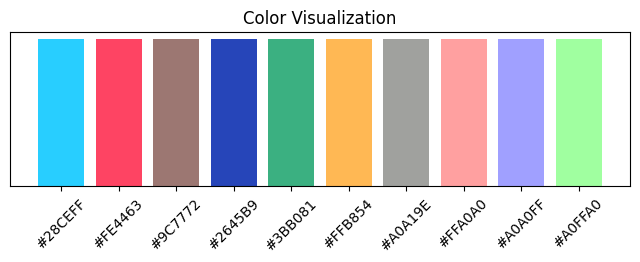

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 2))
for i, color in enumerate(colors):
    plt.bar(i, 1, color=color, width=0.8)
plt.xticks(range(len(colors)), colors, rotation=45)
plt.title("Color Visualization")
plt.yticks([])  # hide y-axis
plt.show()

In [ ]:
# 1. Age groups: 1 for ages 5-12, 2 for ages 13-18
age_groups_mapping = {1: '5-12', 2: '13-18'}

psychostimulant_mapping = {
    0: 'Control',
    1: 'Lisdexamfetamine',
    2: 'Methylphenidate',
    3: 'Lisdexamfetamine & Methylphenidate',
    4: 'Adderall',
    5: 'Dexedrine'
}
tdah_mapping = {0: 'Control', 1: 'TDAH', 2: 'Non-TDAH'}
tsa_mapping = {0: 'Control', 1: 'TSA', 2: 'Non-TSA', 3: 'Potential TSA'}
epilepsy_mapping = {0: 'Control', 1: 'Epilepsy', 2: 'Non-Epilepsy', 3: 'Potential Epilepsy'}
tdah_tsa_mapping = {0: 'Control', 1: 'TDAH and TSA', 2: 'TDAH only', 3: 'TSA only', 4: 'Neither'}
tdah_epi_mapping = {0: 'Control', 1: 'TDAH and Epilepsy', 2: 'TDAH only', 3: 'Epilepsy only', 4: 'Neither'}
tsa_epi_mapping = {0: 'Control', 1: 'TSA and Epilepsy', 2: 'TSA only', 3: 'Epilepsy only', 4: 'Neither'}
tdah_tsa_epi_mapping = {
    0: 'Control',
    1: 'TDAH, TSA & Epilepsy',
    2: 'TDAH & TSA only',
    3: 'TDAH & Epilepsy only',
    4: 'TSA & Epilepsy only',
    5: 'TDAH only',
    6: 'TSA only',
    7: 'Epilepsy only',
    8: 'None'
}

In [ ]:
import pandas as pd

import matplotlib.patches as mpatches

# Create a 3x3 grid to plot all 9 subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (column, mapping) in enumerate(zip(columns, mapping_dicts)):
    # Create a color mapping: sort keys so colors are consistently assigned and assign a color per key
    color_mapping = {k: colors[idx] for idx, k in enumerate(sorted(mapping.keys()))}
    # Map each value in the column to its corresponding color; fill missing mappings with 'grey'
    scatter_colors = df_new[column].map(color_mapping).fillna('grey')
    
    axes[i].scatter(df_new["embedding_1"], df_new["embedding_2"], c=scatter_colors, alpha=0.6)
    axes[i].set_title(f"Embeddings Colored by {column}")
    axes[i].set_xlabel("Embedding Dimension 1")
    axes[i].set_ylabel("Embedding Dimension 2")
    
    # Get unique values (ignoring NaNs) for the legend
    unique_vals = sorted([val for val in df_new[column].unique() if pd.notna(val)])
    handles = [mpatches.Patch(color=color_mapping[val], label=mapping[val]) for val in unique_vals]
    axes[i].legend(handles=handles, title=column, f

plt.tight_layout()
plt.show()

NameError: name 'age_groups_mapping' is not defined

In [ ]:
# select only embeddings and group columns
df_ml = df_new[["embedding_1", "embedding_2", "age_groups", "psychostimulant_category", "TDAH", "TSA", "Epilepsy", "TDAH_TSA", "TDAH_Epilepsy", "TSA_Epilepsy", "TDAH_TSA_Epilepsy"]]

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA transformation
pca = PCA(n_components=2)
trans_pca = pca.fit_transform(embeddings_array)
print("PCA transformation shape:", trans_pca.shape)

# TSNE transformation
tsne = TSNE(n_components=2, random_state=42)
trans_tsne = tsne.fit_transform(embeddings_array)
print("TSNE transformation shape:", trans_tsne.shape)

subject
141    6
175    6
22     6
104    5
221    5
      ..
136    1
187    1
249    1
56     1
156    1
Name: count, Length: 194, dtype: int64

In [155]:
# create random subject_array
subjetcs_array = np.random.randint(1, 251, 400)

In [157]:
# find the index of the last 126 value in subject_array
last_126 = np.where(subjetcs_array == 126)[0]

In [158]:
last_126

array([346])

In [ ]:
# Get unique subjects
unique_subjects = np.unique(subjetcs_array)

AttributeError: 'list' object has no attribute 'unique'

In [ ]:
import logging
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
}

params_grids = {
    "Decision Tree": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["auto", "sqrt", "log2"],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.1, 1],
        "max_depth": [3, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["auto", "sqrt", "log2"],
    },
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 10],
        "weights": ["uniform", "distance"],
        "p": [1, 2],
    },
}
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
from ml_pipelines.pipelines import (
    pipeline_baseline,
    pipeline_feature_selection,
    pipeline_HP_search,
    pipeline_feature_selection_HP_search,
    pipeline_unsupervised,
    get_cv,
)
def pipeline_feature_selection(X, y, num_features, model_name, scoring="accuracy"):
    """
    Feature selection pipeline using SequentialFeatureSelector.
    """
    from sklearn.feature_selection import SequentialFeatureSelector

    cv = get_cv()
    selected_features_dict = {}

    for k in range(1, num_features + 1):
        logging.info(f"Processing {k} features")
        base_model = models.get(model_name)
        if base_model is None:
            raise ValueError(f"Model '{model_name}' is not defined.")
        sfs = SequentialFeatureSelector(
            base_model,
            n_features_to_select=k,
            direction="forward",
            cv=cv,
            n_jobs=-1,
            scoring=scoring
        )
        sfs.fit(X, y)
        selected_features = sfs.get_support(indices=True)
        X_selected = X.iloc[:, selected_features]
        print(X_selected)
        scores = cross_val_score(base_model, X_selected, y, cv=cv, scoring=scoring, n_jobs=-1)
        score_mean = scores.mean()
        logging.info(f"{scoring} with {k} features: {score_mean:.4f}")
        result_dict = {
            "selected_features": selected_features,
            f"{scoring}": score_mean,
            "fitted_model": sfs.estimator
        }
        if hasattr(sfs.estimator, "feature_importances_"):
            result_dict["feature_importances"] = sfs.estimator.feature_importances_
        selected_features_dict[k] = result_dict

    return selected_features_dict

def run_analysis7(features, analysis_type):
    """Multi-feature feature selection (up to 40 features)."""
    X = features.drop("group", axis=1)
    y = features["group"]
    models_result = {}
    for model in ["Decision Tree", "Random Forest", "Gradient Boosting", "K-Nearest Neighbors"]:
        logging.info(f"Running feature selection for model: {model}")
        models_result[model] = pipeline_feature_selection(X, y, 40, model)
    fname = f"feature_selection_all_feat_all_sensors_{analysis_type}.pkl"
    save_results(models_result, fname)
    logging.info("Done analysis 7!")

In [ ]:
from con